In [ ]:
## Load necessary library files ##

import sys
sys.path.append('..')
from sharp.utils import get_sequence, DatasetConverter
from sharp.model.model import Model

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch import from_numpy as tnsr
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm
import pickle 

In [2]:
device = "cpu" 

print("Using device:", device)

Using device: cpu


In [8]:
total_samples, n_community, n_members, context_depth = 1000000, 2, 3, 2
total_layers, short_term_memory = 1, 7

vocab_size = n_community*n_members + 1

In [21]:
class RNN_credit(nn.Module):
    def __init__(self, vocab_size, hidden_size, embedding_dim=30):
        super(RNN_credit, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        
    def forward(self, x, h0=None):
        emb = self.embedding(x)
        out, h0 = self.rnn(emb, h0)
        out = self.fc(h0)
        return out, h0.detach()

In [29]:
# =========================================================
# Experiment
# =========================================================
reps = 10

res = []
repititions = []
samples_seen = []
acc = []


for rep in tqdm(range(reps)):
    model = RNN_credit(vocab_size, hidden_size=100, embedding_dim=30)
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-4, momentum=0.9)
    
    data = get_sequence(
        total_samples,
        n_community,
        n_members,
        context_depth=context_depth,
        train_percent=1.0
    )

    dataset = DatasetConverter(data, short_term_memory=short_term_memory)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    ii = 0
    h_ = None
    correct_ring = np.zeros(1000)
    for x, y in loader:
        x = x.to(device).long()
        y = y.to(device).long()

        logits, h_ = model(x, h_)
        loss = nn.functional.cross_entropy(logits[0], y[0])

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            ii += 1
            pred_tok = logits.argmax(dim=-1)
            correct_ring[ii % 1000] = (pred_tok[0] == y[0, 0]).item()

            if ii%1000 == 0:
                acc = np.sum(correct_ring) / (1000 if ii >= 1000 else ii)
                res.append(acc)
                samples_seen.append(ii)
                repititions.append(rep)

                # print("Iter ", ii, "Acc: ", acc)

# =========================================================
# Save results
# =========================================================
df = pd.DataFrame()
df["reps"] = repititions
df["samples seen"] = samples_seen
df["Accuracy"] = res


with open('../pickle_files/credit_assigned_rnn.pickle', 'wb') as f:
    pickle.dump(df, f)

100%|██████████| 10/10 [1:13:35<00:00, 441.56s/it]


In [9]:
# =========================================================
# Experiment
# =========================================================
reps = 10

res = []
repititions = []
samples_seen = []
acc = []


for rep in tqdm(range(reps)):
    model = Model(
        total_layers=total_layers,

        # ---- Layer sizes ----
        vocab_size=vocab_size,
        hidden_sizes=[100],
        embedding_dim=30,

        # ---- Learning rates per layer ----
        lr_layers=1e-4,

        # ---- Optimizer type ----
        optimizer_class=torch.optim.Adam,
        optimizer_kwargs={
            "weight_decay": 1e-12
        },

        # ---- Sleep hyperparameters ----
        short_term_memory=short_term_memory,
        context_tag_buffer_size=10,

        # ---- Misc ----
        recon_threshold=1e-3,
        device=device
    )
    
    data = get_sequence(
        total_samples,
        n_community,
        n_members,
        context_depth=context_depth,
        train_percent=1.0
    )

    dataset = DatasetConverter(data, short_term_memory=short_term_memory)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    ii = 0
    h_ = None
    correct_ring = np.zeros(1000)
    for x, y in loader:
        x = x.to(device).long()
        y = y.to(device).long()

        logits, loss, recon_loss, h_ = model.wake_step(x, y, h_)
        
        with torch.no_grad():
            ii += 1
            pred_tok = logits.argmax(dim=-1)
            correct_ring[ii % 1000] = (pred_tok[0] == y[0, 0]).item()

            if ii%1000 == 0:
                acc = np.sum(correct_ring) / (1000 if ii >= 1000 else ii)
                res.append(acc)
                samples_seen.append(ii)
                repititions.append(rep)

                # print("Iter ", ii, "Acc: ", acc)

# =========================================================
# Save results
# =========================================================
df = pd.DataFrame()
df["reps"] = repititions
df["samples seen"] = samples_seen
df["Accuracy"] = res


with open('../pickle_files/credit_unassigned_rnn.pickle', 'wb') as f:
    pickle.dump(df, f)

100%|██████████| 10/10 [5:09:09<00:00, 1854.96s/it] 


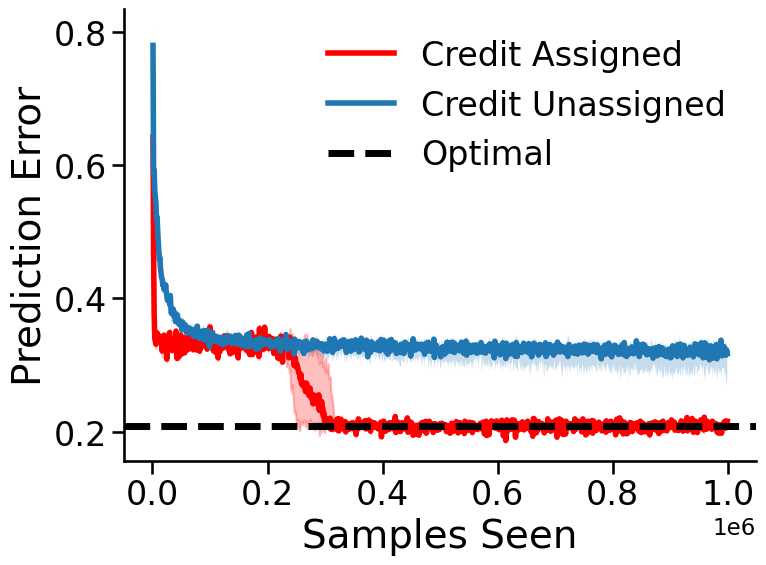

In [17]:
sns.set_context("talk")

# ===================== LOAD =====================
with open('../pickle_files/credit_assigned_rnn.pickle', 'rb') as f:
    df_assigned = pickle.load(f)

with open('../pickle_files/credit_unassigned_rnn.pickle', 'rb') as f:
    df_unassigned = pickle.load(f)

# ===================== SETTINGS =====================
fontsize = 28

# ===================== HELPER =====================
def compute_stats(df):
    g = df.groupby("samples seen")["Accuracy"]
    x = g.median().index.values
    median = g.median().values
    q25 = g.quantile(0.25).values
    q75 = g.quantile(0.75).values
    return x, median, q25, q75

x_a, m_a, q25_a, q75_a = compute_stats(df_assigned)
x_u, m_u, q25_u, q75_u = compute_stats(df_unassigned)

# ===================== PLOT =====================
fig, ax = plt.subplots(figsize=(8,6))

# Credit assigned
ax.plot(x_a, 1-m_a, c='r', linewidth=4, label="Credit Assigned")
ax.fill_between(x_a, 1-q25_a, 1-q75_a, color='r', alpha=0.25)

# Credit unassigned
ax.plot(x_u, 1-m_u, linewidth=4, label="Credit Unassigned")
ax.fill_between(x_u, 1-q25_u, 1-q75_u, alpha=0.25)

chance_acc = 0.7917
chance_err = 1.0 - chance_acc
ax.axhline(chance_err, linestyle="--", color="black", linewidth=5, label="Optimal")

# ===================== STYLE =====================
ax.set_xlabel("Samples Seen", fontsize=fontsize)
ax.set_ylabel("Prediction Error", fontsize=fontsize)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.tick_params(labelsize=fontsize-4)

ax.legend(frameon=False, fontsize=fontsize-4)

plt.tight_layout()
plt.savefig("../plots/credit_assignment_rnn.pdf", bbox_inches="tight")
plt.show()